# Fairness & Causal-Robustness Benchmark

Regenerates every chart and table from the five models' raw result CSVs — `CFFair`, `CLAIRE`, `SRCVAE`, `XGBoost`, `FairPFN`, each with a **Synthetic (SF)** and **Semi-Synthetic (HR)** results file.

**How to use it:** put this notebook in the project root (sibling of `model_results/`), then **Run All**. Charts save to `outputs/charts/`, tables to `outputs/tables/`. Nothing is hand-typed — re-run after refreshing the CSVs and everything updates.


In [72]:
import os, re, json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy.stats import spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})

# ---- EDIT THESE IF YOUR FOLDER LAYOUT DIFFERS ----
DATA_DIR = "model_results"
OUTPUT_DIR = "outputs"
CHARTS_DIR = os.path.join(OUTPUT_DIR, "charts")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

SYN_FILES = {
    "CFFair":  "CFFair_syn_results.csv",
    "CLAIRE":  "CLAIRE_syn_results.csv",
    "SRCVAE":  "SRCVAE_syn_results.csv",
    "XGBoost": "XGBoost_syn_results.csv",
    "FairPFN": "FairPFN_syn_results.csv",
}
SEMI_FILES = {
    "CFFair":  "CFFair_semi_syn_results.csv",
    "CLAIRE":  "CLAIRE_semi_syn_results.csv",
    "SRCVAE":  "SRCVAE_semi_syn_results.csv",
    "XGBoost": "XGBoost_semi_syn_results.csv",
    "FairPFN": "FairPFN_semi_syn_results.csv",
}

MODELS = ["CFFair", "CLAIRE", "SRCVAE", "XGBoost", "FairPFN"]
# ONE consistent color per model, used in every chart in this notebook
COLORS = {"CFFair": "#2563eb", "CLAIRE": "#dc2626", "SRCVAE": "#16a34a", "XGBoost": "#ca8a04", "FairPFN": "#9333ea"}
BIAS_ORDER = ["LowBias", "MedBias", "HighBias", "PolicyDom", "WealthDom"]
DTYPE_ORDER = ["FAIR_ALL", "BIASED_FAIRNESS", "BIASED_MASKED", "BIASED_ALL"]
print('Config OK. Looking for CSVs in:', os.path.abspath(DATA_DIR))


Config OK. Looking for CSVs in: c:\Users\patri\Documents\Master Semesters\2nd semester\APA\Fairness-evaluation-in-the-presence-of-unobserved-unfair-attributes\model_results


## Workflow overview

How every chart in this notebook is produced, end to end.

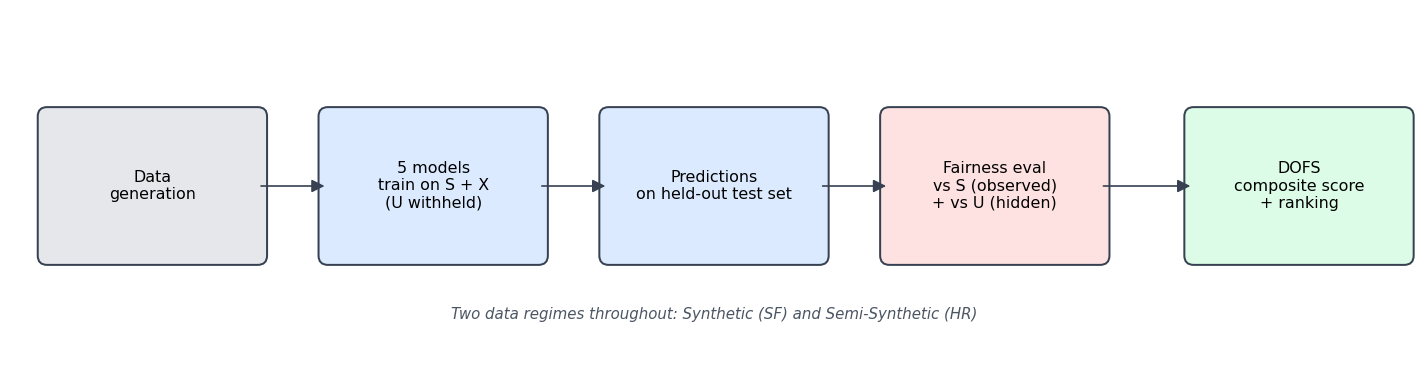

In [73]:
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.set_xlim(0, 12); ax.set_ylim(0, 3); ax.axis('off')

boxes = [
    (0.3, "Data\ngeneration", "#e5e7eb"),
    (2.7, "5 models\ntrain on S + X\n(U withheld)", "#dbeafe"),
    (5.1, "Predictions\non held-out test set", "#dbeafe"),
    (7.5, "Fairness eval\nvs S (observed)\n+ vs U (hidden)", "#fee2e2"),
    (10.1, "DOFS\ncomposite score\n+ ranking", "#dcfce7"),
]
for x, label, color in boxes:
    box = FancyBboxPatch((x, 0.9), 1.8, 1.2, boxstyle="round,pad=0.08",
                          linewidth=1.2, edgecolor="#374151", facecolor=color)
    ax.add_patch(box)
    ax.text(x + 0.9, 1.5, label, ha='center', va='center', fontsize=9.5)

for x0, x1 in [(2.1, 2.7), (4.5, 5.1), (6.9, 7.5), (9.3, 10.1)]:
    ax.add_patch(FancyArrowPatch((x0, 1.5), (x1, 1.5), arrowstyle='-|>', mutation_scale=16, color="#374151"))

ax.text(6, 0.35, "Two data regimes throughout: Synthetic (SF) and Semi-Synthetic (HR)",
        ha='center', fontsize=9, style='italic', color="#4b5563")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'workflow_overview.png'), bbox_inches='tight')
plt.show()


## Load & parse results

Synthetic (SF) filenames encode `base_nodes`, `u_frac`, `seed` — parsed out below. Semi-synthetic (HR) files already carry `bias_level`, `data_type`, `threshold`, `n_U` as columns; only `seed` needs parsing.

In [74]:
def parse_syn_name(name):
    d = {}
    d['sample_size_label'] = 'Large' if 'Large' in name else ('Small' if 'Small' in name else None)
    m2 = re.search(r'(\d+)_base_nodes', name)
    d['base_nodes'] = int(m2.group(1)) if m2 else None
    m3 = re.search(r'u_(\d+)p(\d+)', name)
    d['u_frac'] = float(f"{m3.group(1)}.{m3.group(2)}") if m3 else None
    m4 = re.search(r'seed_(\d+)', name)
    d['seed'] = int(m4.group(1)) if m4 else None
    m5 = re.search(r'(\d+)_nodes_full_data', name)
    d['total_nodes'] = int(m5.group(1)) if m5 else None
    d['nonlinear_pattern'] = 'Linear_ReLU_50%' if 'Linear_ReLU_50%' in name else ('Linear_100%' if 'Linear' in name and 'ReLU' not in name else name)
    return d

def parse_semi_seed(name):
    m = re.search(r'Seed(\d+)', name)
    return int(m.group(1)) if m else None

def load_all():
    dfs_syn = []
    for model, fname in SYN_FILES.items():
        path = os.path.join(DATA_DIR, fname)
        df = pd.read_csv(path)
        df['model_name'] = model
        meta = df['name_dataset'].apply(parse_syn_name).apply(pd.Series)
        df = pd.concat([df, meta], axis=1)
        df['regime'] = 'Synthetic (SF)'
        dfs_syn.append(df)
    syn_all = pd.concat(dfs_syn, ignore_index=True)

    dfs_semi = []
    for model, fname in SEMI_FILES.items():
        path = os.path.join(DATA_DIR, fname)
        df = pd.read_csv(path)
        df['model_name'] = model
        df['seed'] = df['name_dataset'].apply(parse_semi_seed)
        df['regime'] = 'Semi-Synthetic (HR)'
        dfs_semi.append(df)
    semi_all = pd.concat(dfs_semi, ignore_index=True)
    return syn_all, semi_all

syn_all, semi_all = load_all()
print('Synthetic (SF):', syn_all.shape, '| Semi-Synthetic (HR):', semi_all.shape)


Synthetic (SF): (400, 23) | Semi-Synthetic (HR): (6400, 21)


## Composite metric — Distance to Optimal Fair Solution (DOFS)

TOPSIS-style aggregation of 8 metrics (5 predictive + 3 fairness), following Velev & Lessmann's Algorithm 1. `DIR_dist` is a symmetrized, bounded transform of Disparate Impact Ratio (`1 - min(DIR, 1/DIR)`) that safely handles undefined DIR (a group's positive rate hits exactly zero — confirmed present in this data). Reported as **predictive-only**, **fairness-only**, and **combined**.

In [75]:
def add_dofs(df):
    df = df.copy()
    dir_ = df['Disparate_Impact_Ratio'].replace([np.inf, -np.inf], np.nan)
    sym = np.minimum(dir_, 1 / dir_.replace(0, np.nan))
    sym = sym.fillna(0)
    df['DIR_dist'] = 1 - sym

    maximize_cols = ['ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'F1_Score']
    minimize_cols = ['Statistical_Parity_Diff_(ATE)', 'Equal_Opportunity_Diff', 'DIR_dist']
    for c in minimize_cols:
        df[c + '_clip'] = df[c].clip(0, 1)

    best_components, worst_components = [], []
    for c in maximize_cols:
        best_components.append((1 - df[c]) ** 2)
        worst_components.append((0 - df[c]) ** 2)
    for c in minimize_cols:
        v = df[c + '_clip']
        best_components.append((0 - v) ** 2)
        worst_components.append((1 - v) ** 2)
    dist_best = np.sqrt(sum(best_components))
    dist_worst = np.sqrt(sum(worst_components))
    df['DOFS'] = dist_worst / (dist_worst + dist_best)

    pbest = np.sqrt(sum((1 - df[c]) ** 2 for c in maximize_cols))
    pworst = np.sqrt(sum((0 - df[c]) ** 2 for c in maximize_cols))
    df['DOFS_predictive'] = pworst / (pworst + pbest)

    fbest = np.sqrt(sum((0 - df[c + '_clip']) ** 2 for c in minimize_cols))
    fworst = np.sqrt(sum((1 - df[c + '_clip']) ** 2 for c in minimize_cols))
    df['DOFS_fairness'] = fworst / (fworst + fbest)
    return df

syn_all = add_dofs(syn_all)
semi_all = add_dofs(semi_all)
syn_all.to_csv(os.path.join(TABLES_DIR, 'synthetic_SF_with_DOFS.csv'), index=False)
semi_all.to_csv(os.path.join(TABLES_DIR, 'semi_synthetic_HR_with_DOFS.csv'), index=False)

print('Mean DOFS by model — Synthetic (SF):')
print(syn_all.groupby('model_name')[['DOFS', 'DOFS_predictive', 'DOFS_fairness']].mean().round(3))
print()
print('Mean DOFS by model — Semi-Synthetic (HR):')
print(semi_all.groupby('model_name')[['DOFS', 'DOFS_predictive', 'DOFS_fairness']].mean().round(3))


Mean DOFS by model — Synthetic (SF):
             DOFS  DOFS_predictive  DOFS_fairness
model_name                                       
CFFair      0.792            0.850          0.752
CLAIRE      0.764            0.864          0.676
FairPFN     0.820            0.800          0.878
SRCVAE      0.710            0.672          0.796
XGBoost     0.765            0.871          0.672

Mean DOFS by model — Semi-Synthetic (HR):
             DOFS  DOFS_predictive  DOFS_fairness
model_name                                       
CFFair      0.790            0.751          0.904
CLAIRE      0.771            0.755          0.835
FairPFN     0.787            0.753          0.883
SRCVAE      0.695            0.613          0.856
XGBoost     0.757            0.752          0.804


## Data coverage & core comparison subsets

Coverage is checked as a table, not a chart — it's a QC step, not a result. Any cross-model comparison below uses only configurations **every** model was tested on.

In [76]:
cov_syn = syn_all.groupby(['model_name', 'base_nodes', 'u_frac'])['seed'].nunique().unstack(['base_nodes', 'u_frac']).reindex(MODELS)
print('Synthetic (SF): seeds available per model x (base_nodes, u_frac)')
display(cov_syn)
cov_syn.to_csv(os.path.join(TABLES_DIR, 'coverage_synthetic.csv'))

cov_semi = semi_all.groupby(['model_name', 'data_type']).size().unstack().reindex(MODELS)
print()
print('Semi-Synthetic (HR): test-run count per model x data_type')
display(cov_semi)
cov_semi.to_csv(os.path.join(TABLES_DIR, 'coverage_semi_synthetic.csv'))


Synthetic (SF): seeds available per model x (base_nodes, u_frac)


base_nodes  10              20            
u_frac     0.0 0.5 1.0 2.0 0.0 0.5 1.0 2.0
model_name                                
CFFair      10  10  10  10  10  10  10  10
CLAIRE      10  10  10  10  10  10  10  10
SRCVAE      10  10  10  10  10  10  10  10
XGBoost     10  10  10  10  10  10  10  10
FairPFN     10  10  10  10  10  10  10  10


Semi-Synthetic (HR): test-run count per model x data_type


data_type,BIASED_ALL,BIASED_FAIRNESS,BIASED_MASKED,FAIR_ALL
model_name,,,,
CFFair,400.0,400.0,NaN,400.0
CLAIRE,400.0,400.0,NaN,400.0
SRCVAE,400.0,400.0,400.0,400.0
XGBoost,400.0,400.0,NaN,400.0
FairPFN,400.0,400.0,NaN,400.0


In [77]:
# Synthetic core subset: all 5 models now have full u_frac coverage (0.0, 0.5, 1.0, 2.0)
# -- confirmed against the current CSVs, so the core subset is the full dataset (no filtering needed).
syn_core = syn_all.copy()

# Semi-synthetic core subset: BIASED_MASKED is only run for SRCVAE, and n_U has both 0 and 4.
# Restrict to what every model shares: data_type in {BIASED_ALL, FAIR_ALL}, n_U == 4.
semi_core = semi_all[(semi_all['data_type'].isin(['BIASED_ALL', 'FAIR_ALL'])) & (semi_all['n_U'] == 4)].copy()

syn_core.to_csv(os.path.join(TABLES_DIR, 'synthetic_core_subset.csv'), index=False)
semi_core.to_csv(os.path.join(TABLES_DIR, 'semi_synthetic_core_subset.csv'), index=False)

print('Synthetic core subset — rows per model:')
print(syn_core.groupby('model_name').size())
print()
print('Semi-synthetic core subset — rows per model:')
print(semi_core.groupby('model_name').size())


Synthetic core subset — rows per model:
model_name
CFFair     80
CLAIRE     80
FairPFN    80
SRCVAE     80
XGBoost    80
dtype: int64

Semi-synthetic core subset — rows per model:
model_name
CFFair     800
CLAIRE     800
FairPFN    800
SRCVAE     800
XGBoost    800
dtype: int64


## Synthetic (SF) data

All charts below use **line style with markers**, one color per model (matching the semi-synthetic section for direct visual comparison).

### Predictive performance vs. confounding ratio (u_frac)

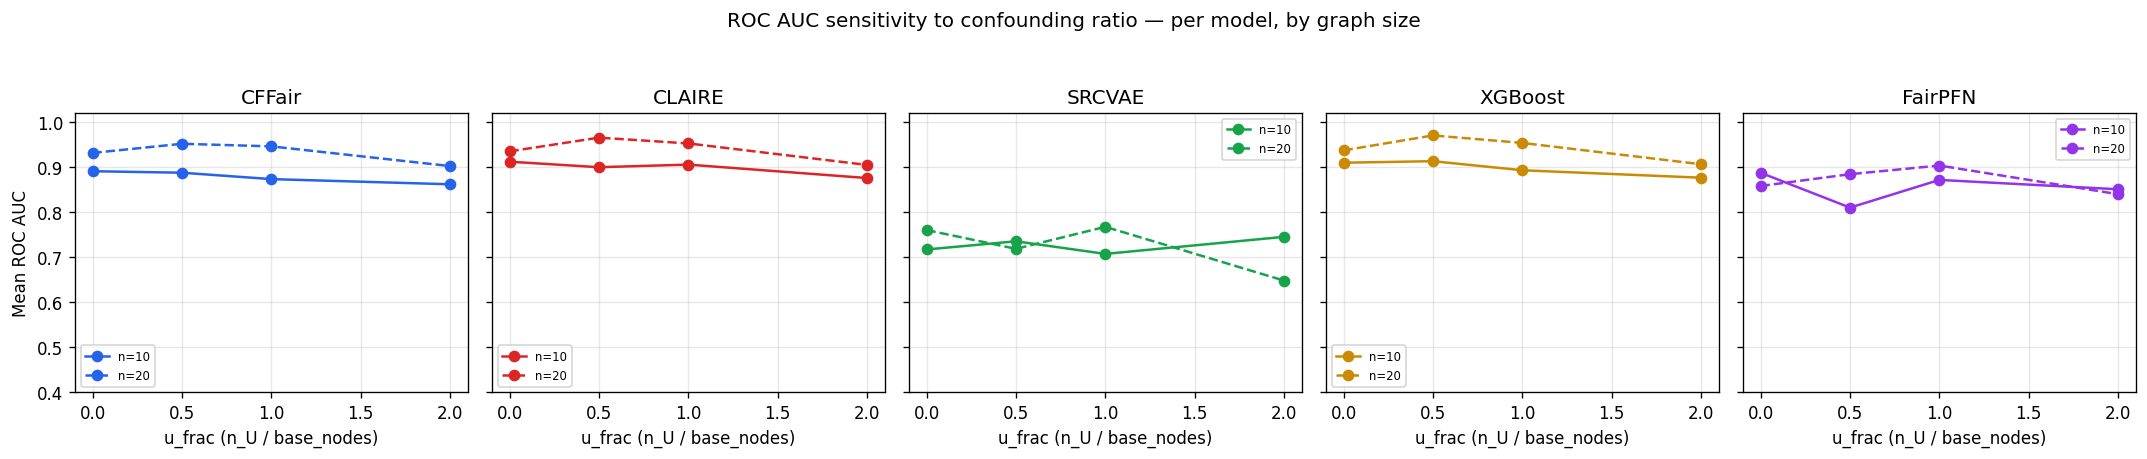

In [78]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = syn_all[syn_all.model_name == model]
    for bn, ls in zip([10, 20], ['-', '--']):
        s2 = sub[sub.base_nodes == bn].groupby('u_frac')['ROC_AUC'].mean()
        if len(s2):
            ax.plot(s2.index, s2.values, marker='o', linestyle=ls, color=COLORS[model], label=f'n={bn}')
    ax.set_title(model); ax.set_xlabel('u_frac (n_U / base_nodes)')
    ax.set_ylim(0.4, 1.02); ax.grid(alpha=0.3); ax.legend(fontsize=7)
axes[0].set_ylabel('Mean ROC AUC')
plt.suptitle('ROC AUC sensitivity to confounding ratio — per model, by graph size', y=1.05)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_rocauc_smallmultiple.png'), bbox_inches='tight')
plt.show()


### Fairness gap vs. confounding ratio

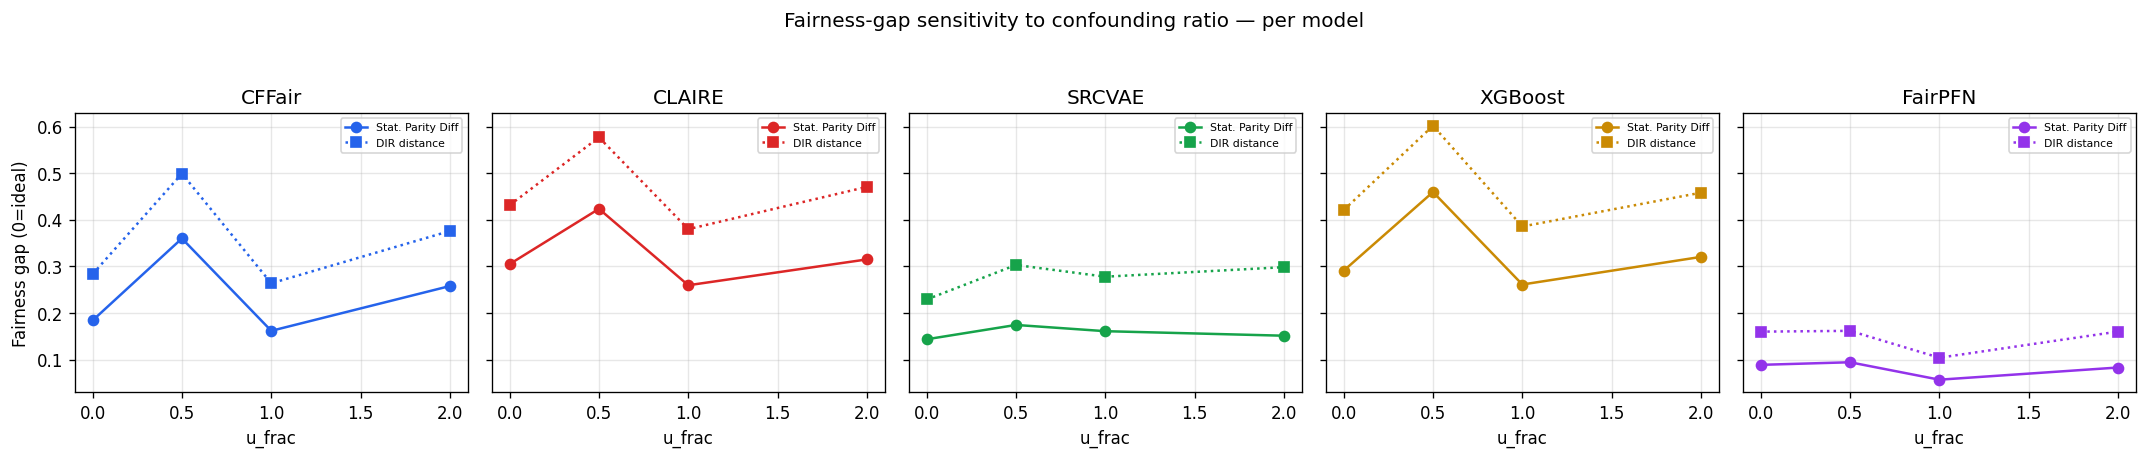

In [79]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = syn_all[syn_all.model_name == model]
    s2 = sub.groupby('u_frac')['Statistical_Parity_Diff_(ATE)'].mean()
    s3 = sub.groupby('u_frac')['DIR_dist'].mean()
    ax.plot(s2.index, s2.values, marker='o', color=COLORS[model], label='Stat. Parity Diff')
    ax.plot(s3.index, s3.values, marker='s', color=COLORS[model], linestyle=':', label='DIR distance')
    ax.set_title(model); ax.set_xlabel('u_frac')
    ax.grid(alpha=0.3); ax.legend(fontsize=6.5)
axes[0].set_ylabel('Fairness gap (0=ideal)')
plt.suptitle('Fairness-gap sensitivity to confounding ratio — per model', y=1.05)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_fairness_smallmultiple.png'), bbox_inches='tight')
plt.show()


### All models combined

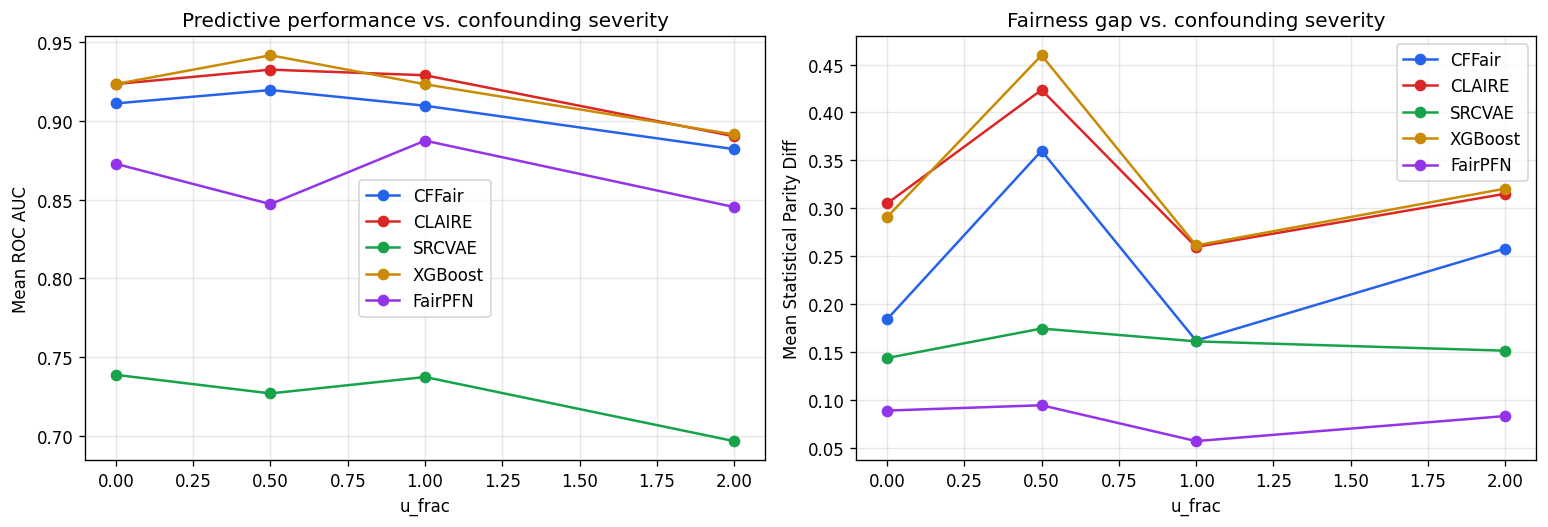

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for model in MODELS:
    sub = syn_all[syn_all.model_name == model].groupby('u_frac')['ROC_AUC'].mean()
    axes[0].plot(sub.index, sub.values, marker='o', color=COLORS[model], label=model)
axes[0].set_xlabel('u_frac'); axes[0].set_ylabel('Mean ROC AUC')
axes[0].set_title('Predictive performance vs. confounding severity')
axes[0].grid(alpha=0.3); axes[0].legend()

for model in MODELS:
    sub = syn_all[syn_all.model_name == model].groupby('u_frac')['Statistical_Parity_Diff_(ATE)'].mean()
    axes[1].plot(sub.index, sub.values, marker='o', color=COLORS[model], label=model)
axes[1].set_xlabel('u_frac'); axes[1].set_ylabel('Mean Statistical Parity Diff')
axes[1].set_title('Fairness gap vs. confounding severity')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_combined_overlay.png'))
plt.show()


### Fairness–Accuracy Frontier

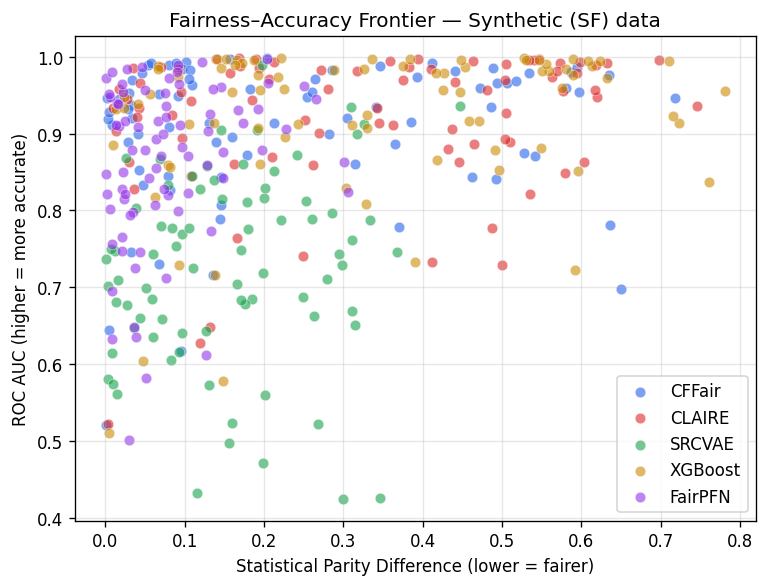

In [81]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for model in MODELS:
    sub = syn_all[syn_all.model_name == model]
    ax.scatter(sub['Statistical_Parity_Diff_(ATE)'], sub['ROC_AUC'], s=40, alpha=0.6,
               color=COLORS[model], label=model, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Statistical Parity Difference (lower = fairer)')
ax.set_ylabel('ROC AUC (higher = more accurate)')
ax.set_title('Fairness–Accuracy Frontier — Synthetic (SF) data')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_frontier.png'))
plt.show()


### Composite DOFS by model

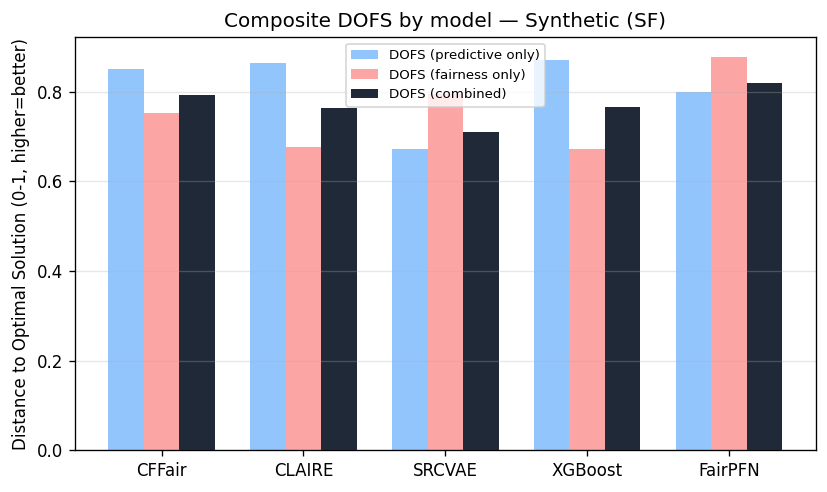

,DOFS,DOFS_predictive,DOFS_fairness
model_name,,,
CFFair,0.792,0.850,0.752
CLAIRE,0.764,0.864,0.676
SRCVAE,0.710,0.672,0.796
XGBoost,0.765,0.871,0.672
FairPFN,0.820,0.800,0.878


In [82]:
means = syn_core.groupby('model_name')[['DOFS', 'DOFS_predictive', 'DOFS_fairness']].mean().reindex(MODELS)
fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(MODELS)); w = 0.25
ax.bar(x - w, means['DOFS_predictive'], width=w, label='DOFS (predictive only)', color='#93c5fd')
ax.bar(x, means['DOFS_fairness'], width=w, label='DOFS (fairness only)', color='#fca5a5')
ax.bar(x + w, means['DOFS'], width=w, label='DOFS (combined)', color='#1f2937')
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.set_ylabel('Distance to Optimal Solution (0-1, higher=better)')
ax.set_title('Composite DOFS by model — Synthetic (SF)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_dofs_bar.png'))
plt.show()
display(means.round(3))


## Semi-Synthetic (HR) data

Same chart types as the synthetic section above — line charts with markers, one color per model — for direct visual comparability across regimes.

### Predictive performance by bias scenario

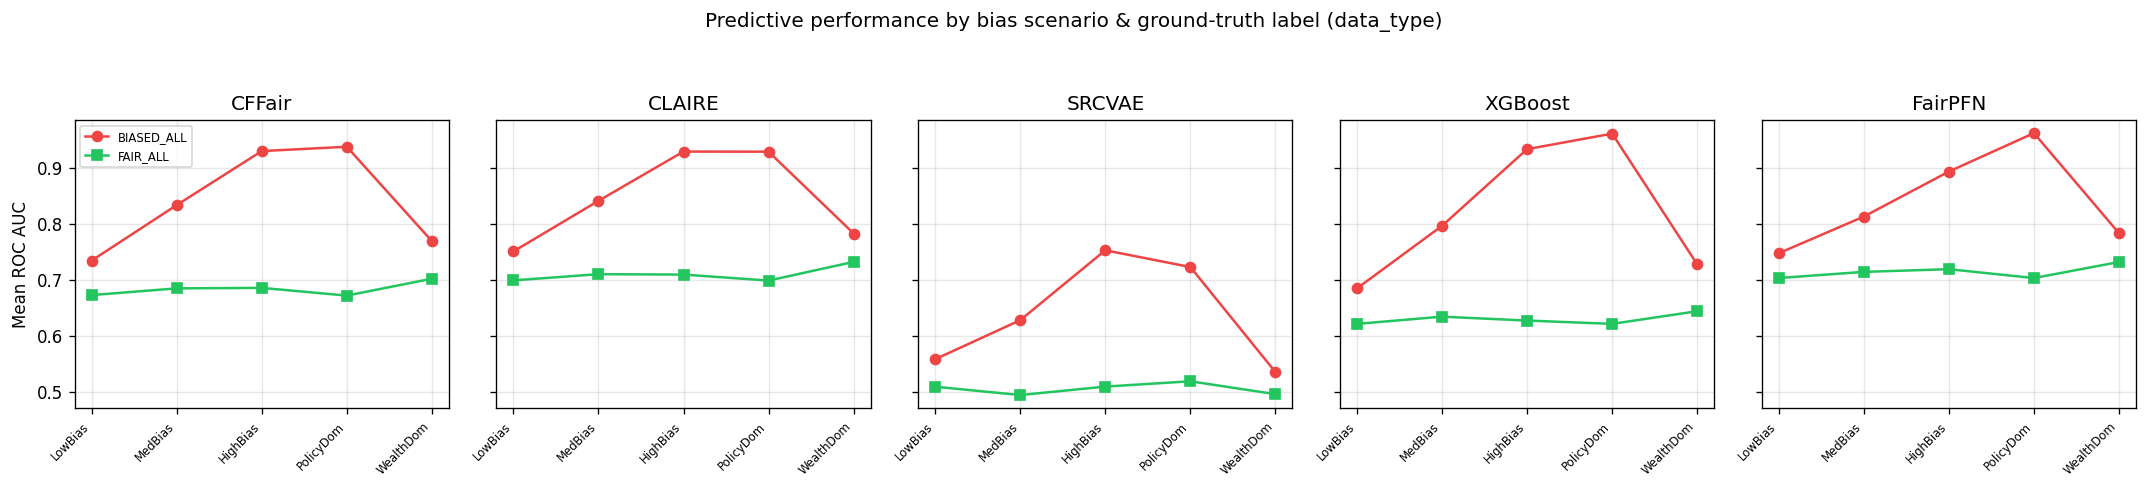

In [83]:
core_dtypes = ['BIASED_ALL', 'FAIR_ALL']
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = semi_all[(semi_all.model_name == model) & (semi_all.data_type.isin(core_dtypes))]
    piv = sub.groupby(['bias_level', 'data_type'])['ROC_AUC'].mean().unstack().reindex(BIAS_ORDER)
    x = np.arange(len(BIAS_ORDER))
    for dt, color, marker in zip(core_dtypes, ['#ef4444', '#22c55e'], ['o', 's']):
        if dt in piv.columns:
            ax.plot(x, piv[dt].values, marker=marker, color=color, label=dt)
    ax.set_xticks(x); ax.set_xticklabels(BIAS_ORDER, rotation=45, ha='right', fontsize=7)
    ax.set_title(model); ax.grid(alpha=0.3)
    if model == 'CFFair':
        ax.legend(fontsize=7)
axes[0].set_ylabel('Mean ROC AUC')
plt.suptitle('Predictive performance by bias scenario & ground-truth label (data_type)', y=1.06)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_rocauc_smallmultiple.png'), bbox_inches='tight')
plt.show()


### Bias-detection sanity check — SPD by data_type

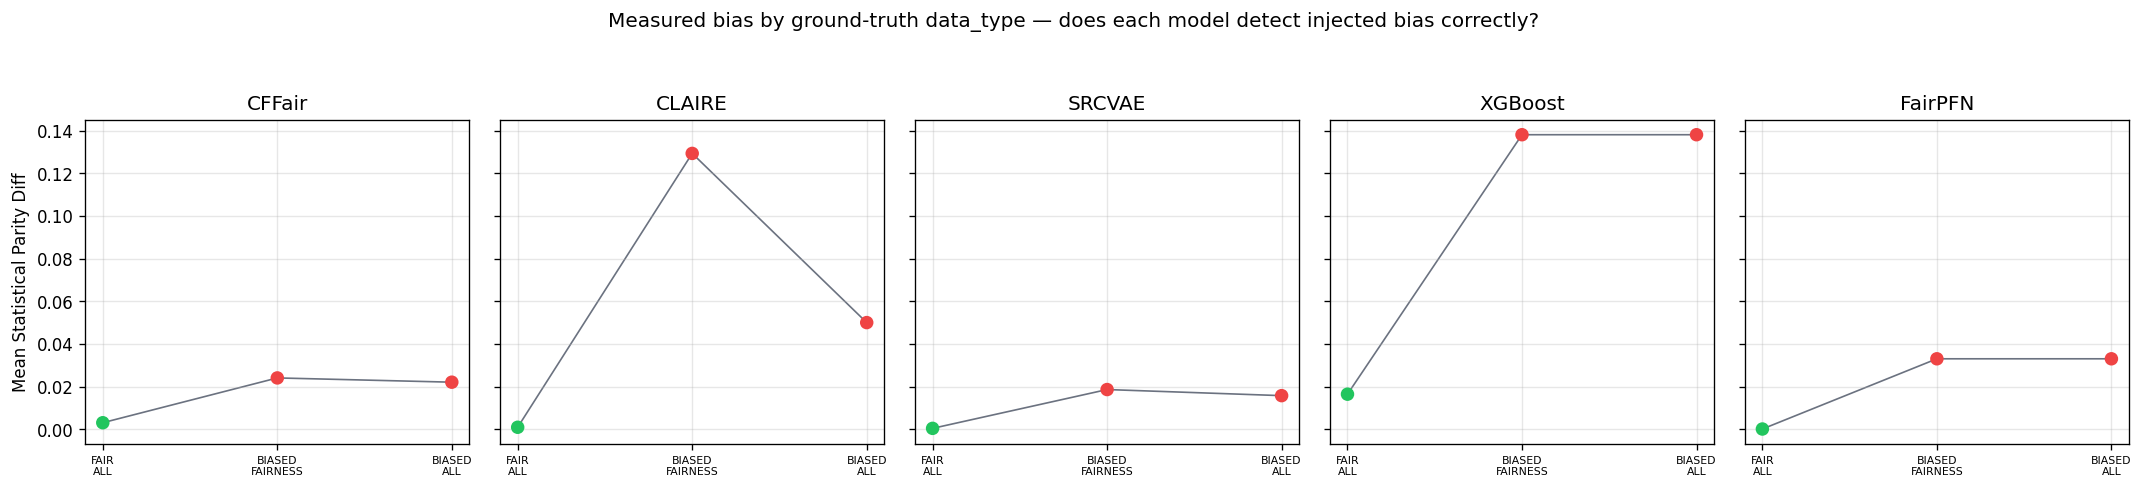

Bias-detection gap (BIASED_ALL minus FAIR_ALL, mean SPD):


data_type,BIASED_ALL,FAIR_ALL,detection_gap
model_name,,,
XGBoost,0.1381,0.0165,0.1216
CLAIRE,0.0501,0.0010,0.0490
FairPFN,0.0331,0.0002,0.0329
CFFair,0.0222,0.0032,0.0190
SRCVAE,0.0159,0.0005,0.0153


In [84]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = semi_all[semi_all.model_name == model]
    piv = sub.groupby('data_type')['Statistical_Parity_Diff_(ATE)'].mean().reindex(DTYPE_ORDER).dropna()
    x = np.arange(len(piv))
    point_colors = ['#ef4444' if 'BIASED' in d else '#22c55e' for d in piv.index]
    ax.plot(x, piv.values, color='#6b7280', linewidth=1, zorder=1)
    ax.scatter(x, piv.values, color=point_colors, s=50, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels([d.replace('_', '\n') for d in piv.index], fontsize=6.5)
    ax.set_title(model); ax.grid(alpha=0.3)
axes[0].set_ylabel('Mean Statistical Parity Diff')
plt.suptitle('Measured bias by ground-truth data_type — does each model detect injected bias correctly?', y=1.06)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_spd_by_datatype.png'), bbox_inches='tight')
plt.show()

print('Bias-detection gap (BIASED_ALL minus FAIR_ALL, mean SPD):')
gap = semi_all.groupby(['model_name', 'data_type'])['Statistical_Parity_Diff_(ATE)'].mean().unstack()[['BIASED_ALL', 'FAIR_ALL']]
gap['detection_gap'] = gap['BIASED_ALL'] - gap['FAIR_ALL']
display(gap.round(4).sort_values('detection_gap', ascending=False))


### Effect of hiring threshold

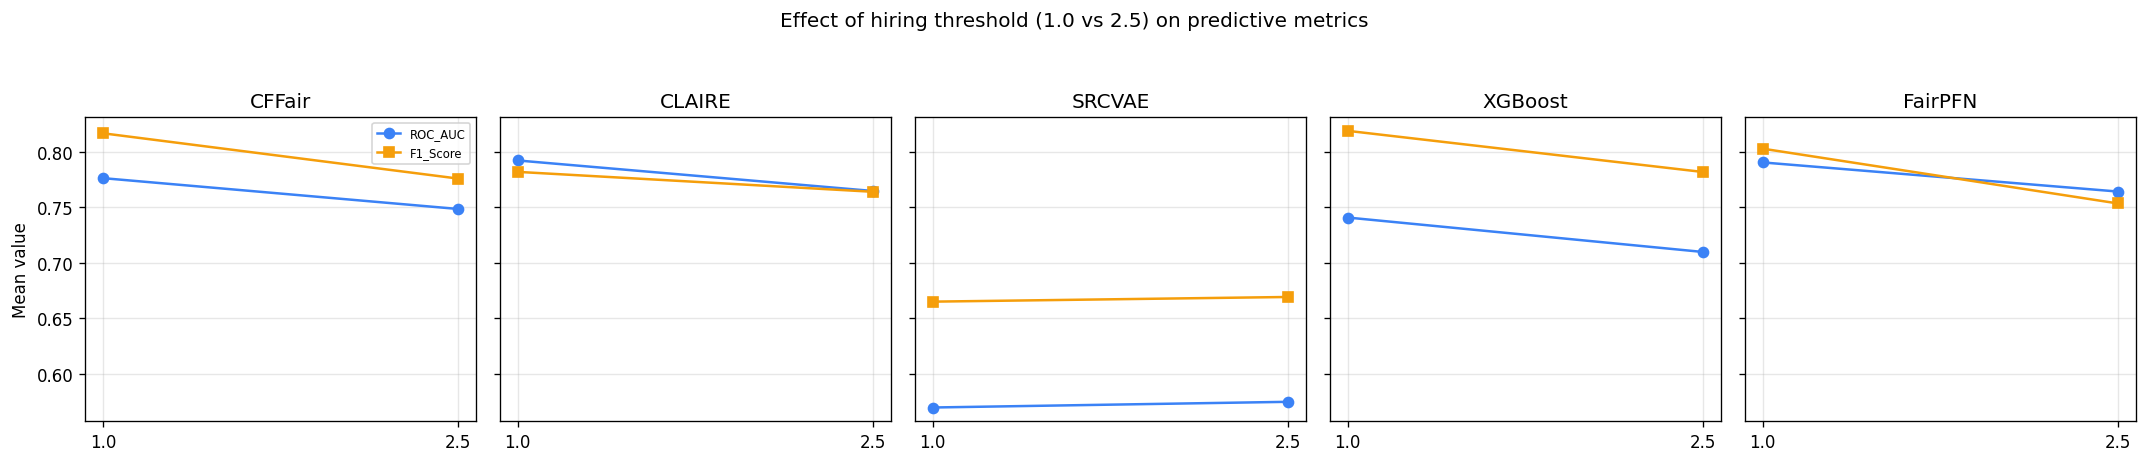

In [85]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = semi_all[(semi_all.model_name == model) & (semi_all.data_type.isin(core_dtypes))]
    piv = sub.groupby('threshold')[['ROC_AUC', 'F1_Score']].mean()
    x = np.arange(len(piv))
    ax.plot(x, piv['ROC_AUC'].values, marker='o', color='#3b82f6', label='ROC_AUC')
    ax.plot(x, piv['F1_Score'].values, marker='s', color='#f59e0b', label='F1_Score')
    ax.set_xticks(x); ax.set_xticklabels(piv.index)
    ax.set_title(model); ax.grid(alpha=0.3)
    if model == 'CFFair':
        ax.legend(fontsize=7)
axes[0].set_ylabel('Mean value')
plt.suptitle('Effect of hiring threshold (1.0 vs 2.5) on predictive metrics', y=1.06)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_threshold_effect.png'), bbox_inches='tight')
plt.show()


### All models combined

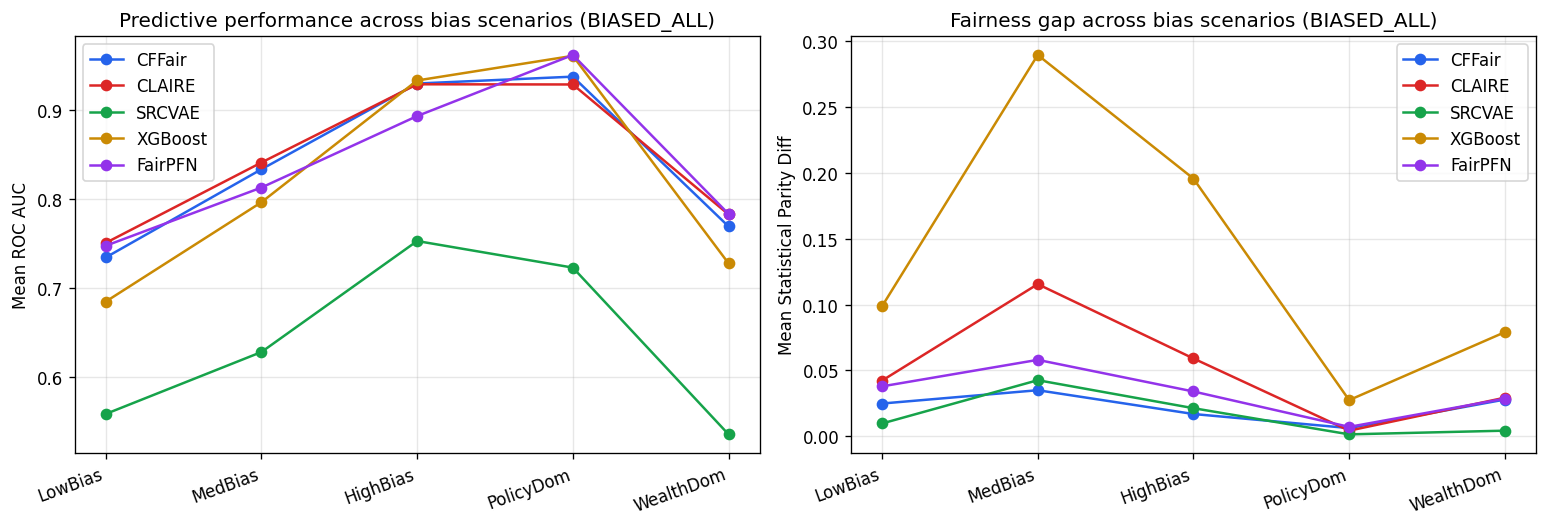

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for model in MODELS:
    sub = semi_all[(semi_all.model_name == model) & (semi_all.data_type == 'BIASED_ALL')]
    s = sub.groupby('bias_level')['ROC_AUC'].mean().reindex(BIAS_ORDER)
    axes[0].plot(range(len(s)), s.values, marker='o', color=COLORS[model], label=model)
axes[0].set_xticks(range(len(BIAS_ORDER))); axes[0].set_xticklabels(BIAS_ORDER, rotation=20, ha='right')
axes[0].set_ylabel('Mean ROC AUC'); axes[0].set_title('Predictive performance across bias scenarios (BIASED_ALL)')
axes[0].grid(alpha=0.3); axes[0].legend()

for model in MODELS:
    sub = semi_all[(semi_all.model_name == model) & (semi_all.data_type == 'BIASED_ALL')]
    s = sub.groupby('bias_level')['Statistical_Parity_Diff_(ATE)'].mean().reindex(BIAS_ORDER)
    axes[1].plot(range(len(s)), s.values, marker='o', color=COLORS[model], label=model)
axes[1].set_xticks(range(len(BIAS_ORDER))); axes[1].set_xticklabels(BIAS_ORDER, rotation=20, ha='right')
axes[1].set_ylabel('Mean Statistical Parity Diff'); axes[1].set_title('Fairness gap across bias scenarios (BIASED_ALL)')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_combined_overlay.png'))
plt.show()


### Fairness–Accuracy Frontier

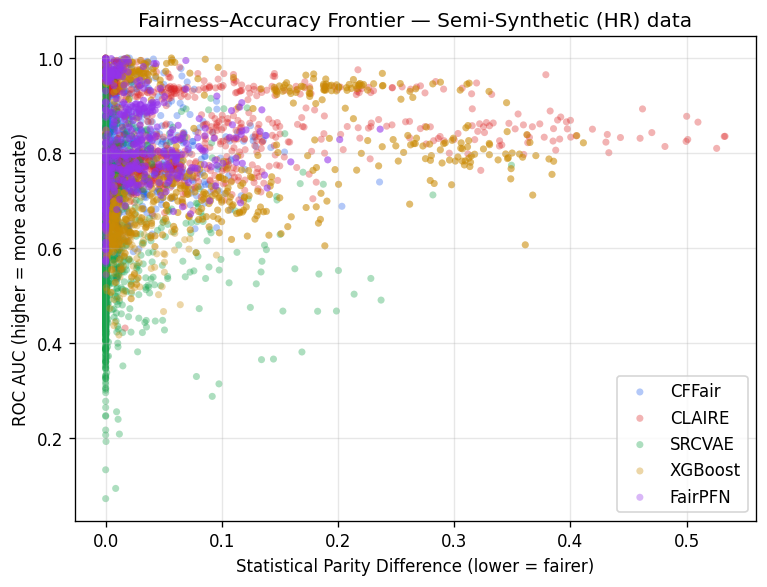

In [87]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for model in MODELS:
    sub = semi_all[semi_all.model_name == model]
    ax.scatter(sub['Statistical_Parity_Diff_(ATE)'], sub['ROC_AUC'], s=18, alpha=0.35,
               color=COLORS[model], label=model, edgecolor='none')
ax.set_xlabel('Statistical Parity Difference (lower = fairer)')
ax.set_ylabel('ROC AUC (higher = more accurate)')
ax.set_title('Fairness–Accuracy Frontier — Semi-Synthetic (HR) data')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_frontier.png'))
plt.show()


### Composite DOFS by model

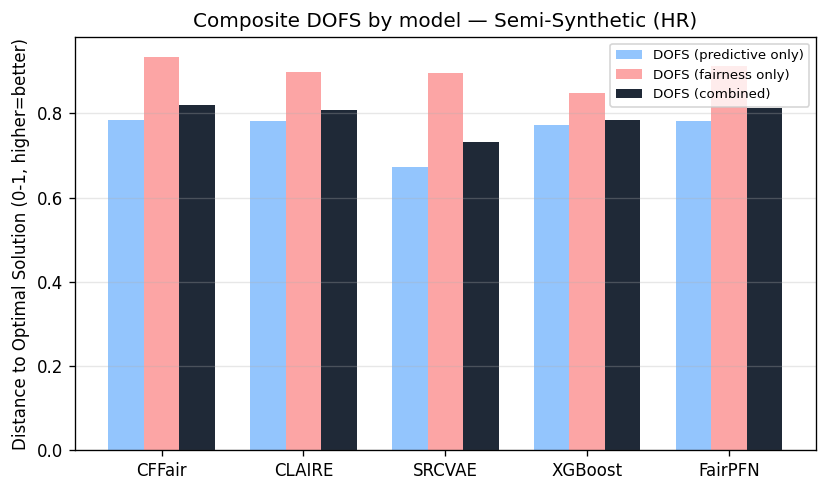

,DOFS,DOFS_predictive,DOFS_fairness
model_name,,,
CFFair,0.821,0.784,0.935
CLAIRE,0.809,0.781,0.897
SRCVAE,0.731,0.672,0.895
XGBoost,0.784,0.771,0.849
FairPFN,0.814,0.781,0.912


In [88]:
means_semi = semi_core.groupby('model_name')[['DOFS', 'DOFS_predictive', 'DOFS_fairness']].mean().reindex(MODELS)
fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(MODELS)); w = 0.25
ax.bar(x - w, means_semi['DOFS_predictive'], width=w, label='DOFS (predictive only)', color='#93c5fd')
ax.bar(x, means_semi['DOFS_fairness'], width=w, label='DOFS (fairness only)', color='#fca5a5')
ax.bar(x + w, means_semi['DOFS'], width=w, label='DOFS (combined)', color='#1f2937')
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.set_ylabel('Distance to Optimal Solution (0-1, higher=better)')
ax.set_title('Composite DOFS by model — Semi-Synthetic (HR)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_dofs_bar.png'))
plt.show()
display(means_semi.round(3))


## Cross-model ranking

Ranks each model on every metric plus combined DOFS (1=best), then checks whether DOFS tracks one metric or genuinely aggregates (Spearman rank correlation).

In [89]:
metrics = ['F1_Score', 'ROC_AUC', 'Recall', 'Statistical_Parity_Diff_(ATE)', 'Equal_Opportunity_Diff', 'DIR_dist', 'DOFS']
ascending_map = {'F1_Score': False, 'ROC_AUC': False, 'Recall': False,
                 'Statistical_Parity_Diff_(ATE)': True, 'Equal_Opportunity_Diff': True, 'DIR_dist': True, 'DOFS': False}

def rank_table(df, label):
    means = df.groupby('model_name')[metrics].mean().reindex(MODELS)
    ranks = pd.DataFrame(index=means.index)
    for m in metrics:
        ranks[m] = means[m].rank(ascending=ascending_map[m]).astype(int)
    print(f'=== {label}: mean values ===')
    display(means.round(4))
    print(f'=== {label}: rank table (1=best) ===')
    display(ranks)
    print(f'=== {label}: Spearman corr of DOFS rank vs each metric rank ===')
    for m in metrics[:-1]:
        rho, p = spearmanr(ranks['DOFS'], ranks[m])
        print(f'  {m}: rho={rho:.3f}')
    print()
    means.to_csv(os.path.join(TABLES_DIR, f'{label.replace(" ", "_").lower()}_means.csv'))
    ranks.to_csv(os.path.join(TABLES_DIR, f'{label.replace(" ", "_").lower()}_ranks.csv'))
    return means, ranks

syn_means, syn_ranks = rank_table(syn_core, 'SYN core')
semi_means, semi_ranks = rank_table(semi_core, 'SEMI core')


=== SYN core: mean values ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,0.8390,0.9056,0.8262,0.2410,0.1170,0.3557,0.7922
CLAIRE,0.8545,0.9188,0.8461,0.3259,0.1549,0.4648,0.7641
SRCVAE,0.6514,0.7249,0.6662,0.1577,0.1397,0.2772,0.7101
XGBoost,0.8615,0.9199,0.8535,0.3331,0.1555,0.4667,0.7647
FairPFN,0.7848,0.8631,0.7912,0.0809,0.1060,0.1466,0.8202


=== SYN core: rank table (1=best) ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,3,3,3,3,2,3,2
CLAIRE,2,2,2,4,4,4,4
SRCVAE,5,5,5,2,3,2,5
XGBoost,1,1,1,5,5,5,3
FairPFN,4,4,4,1,1,1,1


=== SYN core: Spearman corr of DOFS rank vs each metric rank ===
  F1_Score: rho=0.100
  ROC_AUC: rho=0.100
  Recall: rho=0.100
  Statistical_Parity_Diff_(ATE): rho=0.300
  Equal_Opportunity_Diff: rho=0.600
  DIR_dist: rho=0.300

=== SEMI core: mean values ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,0.7962,0.7623,0.8135,0.0127,0.0693,0.0891,0.8210
CLAIRE,0.7729,0.7783,0.8000,0.0256,0.0438,0.1968,0.8091
SRCVAE,0.6671,0.5723,0.7154,0.0082,0.0106,0.2366,0.7311
XGBoost,0.8002,0.7252,0.8092,0.0773,0.0956,0.2578,0.7844
FairPFN,0.7780,0.7772,0.8010,0.0167,0.0653,0.1462,0.8137


=== SEMI core: rank table (1=best) ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,2,3,1,2,4,1,1
CLAIRE,4,1,4,4,2,3,3
SRCVAE,5,5,5,1,1,4,5
XGBoost,1,4,2,5,5,5,4
FairPFN,3,2,3,3,3,2,2


=== SEMI core: Spearman corr of DOFS rank vs each metric rank ===
  F1_Score: rho=0.400
  ROC_AUC: rho=0.600
  Recall: rho=0.700
  Statistical_Parity_Diff_(ATE): rho=0.000
  Equal_Opportunity_Diff: rho=-0.400
  DIR_dist: rho=0.900



### Final cross-regime DOFS comparison

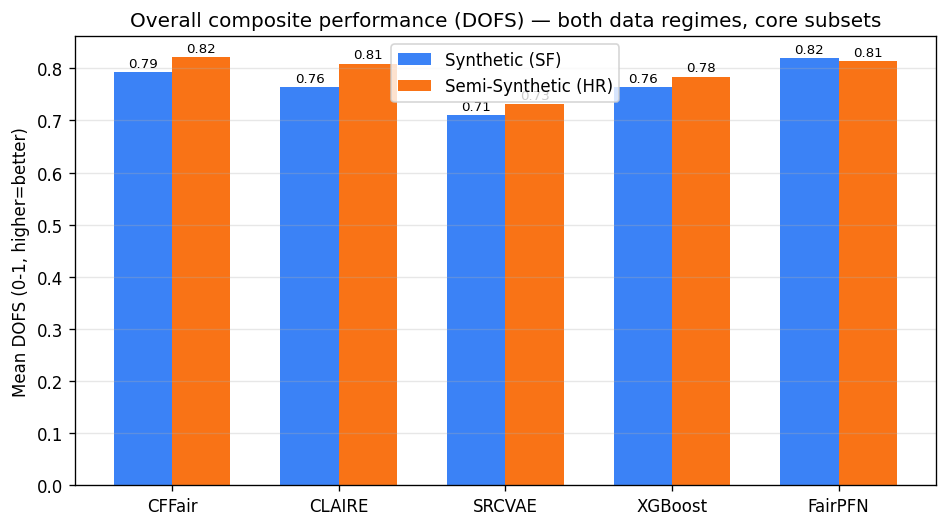

In [90]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(MODELS)); w = 0.35
ax.bar(x - w/2, syn_means['DOFS'], width=w, label='Synthetic (SF)', color='#3b82f6')
ax.bar(x + w/2, semi_means['DOFS'], width=w, label='Semi-Synthetic (HR)', color='#f97316')
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.set_ylabel('Mean DOFS (0-1, higher=better)')
ax.set_title('Overall composite performance (DOFS) — both data regimes, core subsets')
ax.legend(); ax.grid(alpha=0.3, axis='y')
for i, v in enumerate(syn_means['DOFS']): ax.text(i - w/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
for i, v in enumerate(semi_means['DOFS']): ax.text(i + w/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'dofs_final_comparison.png'))
plt.show()


## Sensitivity analysis

InterpretML's Explainable Boosting Machine (used in the source paper) needs network access to install; `HistGradientBoostingRegressor` + permutation importance substitutes for the same "what drives the outcome" reading.

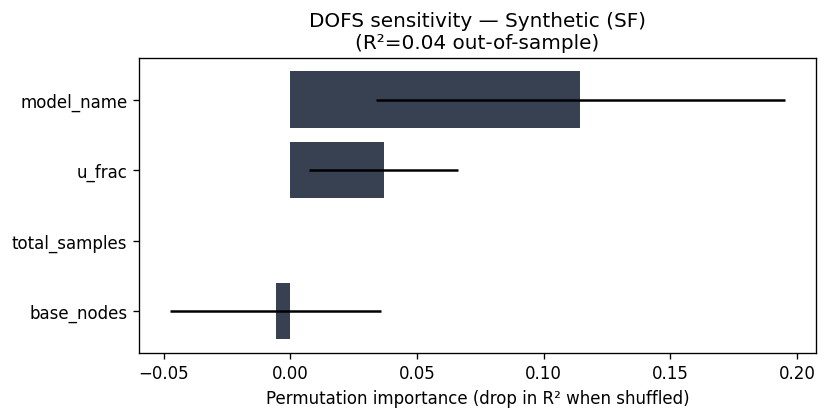

SF importance: {'model_name': 0.1145, 'base_nodes': -0.0059, 'u_frac': 0.0368, 'total_samples': 0.0}  R2: 0.04


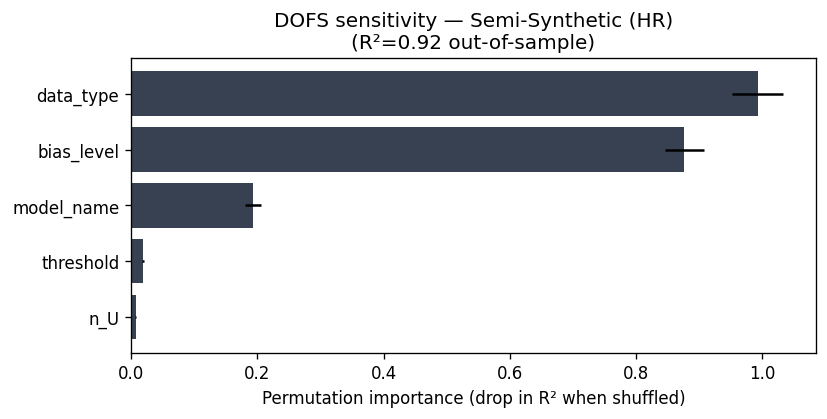

HR importance: {'model_name': 0.1936, 'bias_level': 0.8762, 'data_type': 0.9922, 'threshold': 0.0195, 'n_U': 0.0078}  R2: 0.921


In [91]:
def run_importance(df, features, target, cat_features, title, fname):
    d = df[features + [target]].dropna().copy()
    for c in cat_features:
        d[c] = d[c].astype('category').cat.codes
    X = d[features]; y = d[target]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
    model = HistGradientBoostingRegressor(random_state=42, max_depth=4)
    model.fit(Xtr, ytr)
    r2 = model.score(Xte, yte)
    imp = permutation_importance(model, Xte, yte, n_repeats=20, random_state=42)
    order = np.argsort(imp.importances_mean)[::-1]
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.barh([features[i] for i in order][::-1], imp.importances_mean[order][::-1],
            xerr=imp.importances_std[order][::-1], color='#374151')
    ax.set_xlabel('Permutation importance (drop in R\u00b2 when shuffled)')
    ax.set_title(f'{title}\n(R\u00b2={r2:.2f} out-of-sample)', fontsize=12)
    plt.tight_layout(); plt.savefig(fname)
    plt.show()
    return dict(zip(features, imp.importances_mean)), r2

syn_features = ['model_name', 'base_nodes', 'u_frac', 'total_samples']
imp_syn, r2_syn = run_importance(syn_all, syn_features, 'DOFS', ['model_name'],
                                  'DOFS sensitivity — Synthetic (SF)',
                                  os.path.join(CHARTS_DIR, 'syn_importance.png'))
print('SF importance:', {k: round(v, 4) for k, v in imp_syn.items()}, ' R2:', round(r2_syn, 3))

semi_features = ['model_name', 'bias_level', 'data_type', 'threshold', 'n_U']
imp_semi, r2_semi = run_importance(semi_all, semi_features, 'DOFS', ['model_name', 'bias_level', 'data_type'],
                                    'DOFS sensitivity — Semi-Synthetic (HR)',
                                    os.path.join(CHARTS_DIR, 'semi_importance.png'))
print('HR importance:', {k: round(v, 4) for k, v in imp_semi.items()}, ' R2:', round(r2_semi, 3))


### Interaction effects (model × scenario), as line overlays — not heatmaps

Same chart language as the combined-overlay sections above, so the interaction view stays visually consistent with the rest of the notebook.

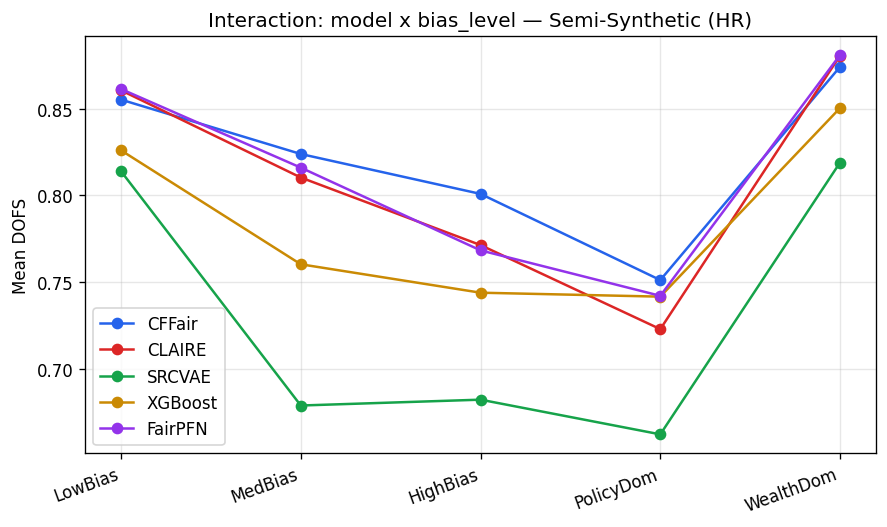

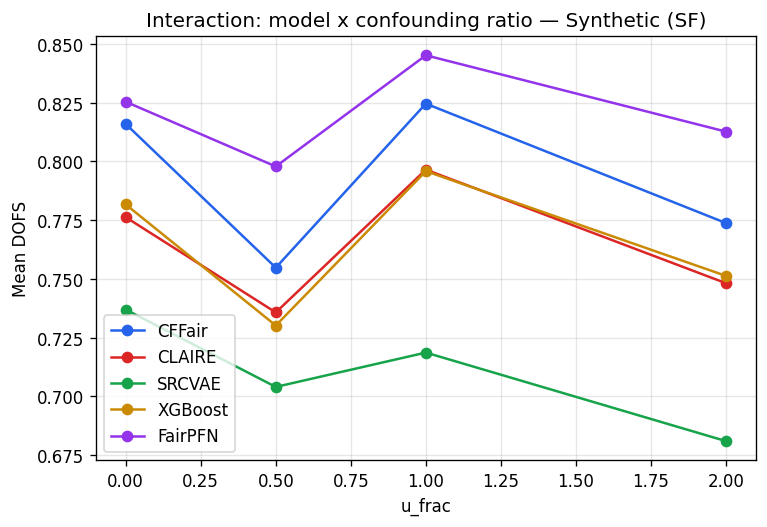

In [92]:
core = semi_all[(semi_all.data_type.isin(['BIASED_ALL', 'FAIR_ALL'])) & (semi_all.n_U == 4)]
piv = core.groupby(['model_name', 'bias_level'])['DOFS'].mean().unstack().reindex(MODELS)[BIAS_ORDER]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for model in MODELS:
    ax.plot(range(len(BIAS_ORDER)), piv.loc[model].values, marker='o', color=COLORS[model], label=model)
ax.set_xticks(range(len(BIAS_ORDER))); ax.set_xticklabels(BIAS_ORDER, rotation=20, ha='right')
ax.set_ylabel('Mean DOFS'); ax.set_title('Interaction: model x bias_level — Semi-Synthetic (HR)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_interaction_model_bias.png'))
plt.show()

core2 = syn_all[syn_all.u_frac.isin([0.0, 0.5, 1.0, 2.0])]
piv2 = core2.groupby(['model_name', 'u_frac'])['DOFS'].mean().unstack().reindex(MODELS)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for model in MODELS:
    ax.plot(piv2.columns, piv2.loc[model].values, marker='o', color=COLORS[model], label=model)
ax.set_xlabel('u_frac'); ax.set_ylabel('Mean DOFS')
ax.set_title('Interaction: model x confounding ratio — Synthetic (SF)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_interaction_model_ufrac.png'))
plt.show()


## Fairness with respect to hidden attributes (U) — pending

The core contribution this project is meant to demonstrate: fairness isn't only about the observed attribute `S`, but also about hidden confounders `U`. Every chart above evaluates fairness with respect to `S`. This section is not yet possible with the current data.

**Why:** the result CSVs store one row per (model, dataset) with *aggregate* metrics only. Computing SPD/EOD/DIR with respect to `U` needs, for every test-set individual: their prediction, and their `U` value(s) — neither is currently saved.

**What's needed before this section can be built:**
1. Each of the five model notebooks needs to additionally save per-sample test predictions alongside `S`, `Y`, and `U` for every test row (a new detail file per model/regime, separate from the aggregate results CSV).
2. Since `U` is continuous and can have multiple columns (`n_U` varies), group definitions need either equal-frequency binning (single-`U` cases) or k-means clustering (generalizes across any `n_U`) — clustering is the more consistent default across configurations.
3. The same SPD/EOD/DIR/DOFS machinery already built above then runs a second time, keyed on `U`-derived groups instead of `S`.

Once the per-sample logging is added to the model notebooks and re-run, this section plugs in the same chart style as the rest of this notebook (line overlays, `COLORS` per model) for direct comparison against the `S`-based results already shown.


## Done

**To refresh with new results:** overwrite the 10 CSVs (same filenames) in `model_results/` and re-run all cells — every number, chart, and table above updates automatically. No hand-typed values anywhere in this notebook.